In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

,Date,Open,High,Low,Close,Adj Close,Volume,ma
0,2020-06-29,89.580002,89.699997,88.089996,89.010002,86.375900,4669300,86.375900
1,2020-06-30,88.750000,91.900002,88.440002,91.430000,88.724289,5220900,88.724289
2,2020-07-01,91.980003,91.980003,90.430000,91.639999,88.928078,3389600,88.928078
3,2020-07-02,92.500000,93.059998,91.930000,92.230003,89.500633,3845300,89.500633
4,2020-07-06,92.760002,93.970001,92.449997,92.970001,90.218719,5919100,90.218719


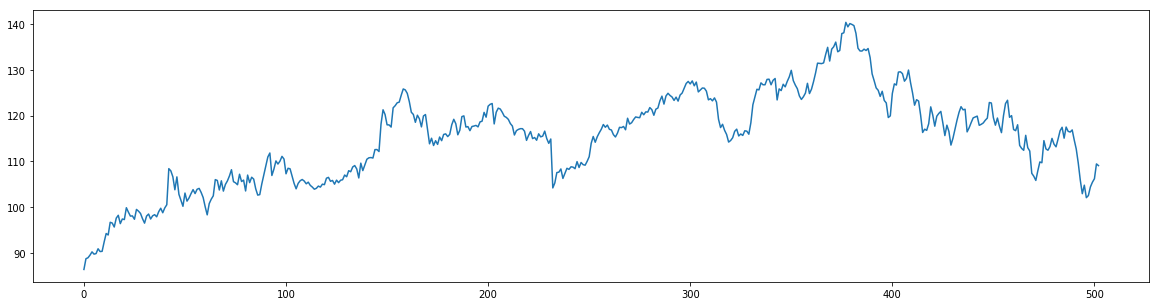

In [2]:
rawdata = pd.read_csv("C:/Users/le/Desktop/TimeSeriesForecast-Transformer-main/TimeSeriesForecast-Transformer-main/ABT.csv", encoding='CP949')
plt.figure(figsize=(20,5))
#plt.plot(range(len(rawdata)), rawdata["Adj Close"])
j = 0
rawdata['ma'] = rawdata['Adj Close'].rolling(j+1).mean()
rawdata = rawdata[j:]
plt.plot(range(len(rawdata)), rawdata["ma"])
rawdata.head()

In [3]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()
rawdata["ma"] = min_max_scaler.fit_transform(rawdata["ma"].to_numpy().reshape(-1,1))


In [4]:
train = rawdata[:-16*7]
data_train = train["ma"].to_numpy()

test = rawdata[-16*7:]
data_test = test["ma"].to_numpy()

In [5]:
import torch
import torch.nn as nn
import numpy as np
import math
import torch.nn.functional as F

# FC Layer decoder

In [6]:
from torch.utils.data import DataLoader, Dataset
class windowDataset(Dataset):
    def __init__(self, y, input_window=80, output_window=20, stride=5):
        #총 데이터의 개수
        L = y.shape[0]
        #stride씩 움직일 때 생기는 총 sample의 개수
        num_samples = (L - input_window - output_window) // stride + 1
        print(L - input_window - output_window)

        #input과 output
        X = np.zeros([input_window, num_samples])
        Y = np.zeros([output_window, num_samples])

        for i in np.arange(num_samples):
            start_x = stride*i
            end_x = start_x + input_window
            X[:,i] = y[start_x:end_x]

            start_y = stride*i + input_window
            end_y = start_y + output_window
            Y[:,i] = y[start_y:end_y]

        X = X.reshape(X.shape[0], X.shape[1], 1).transpose((1,0,2))
        Y = Y.reshape(Y.shape[0], Y.shape[1], 1).transpose((1,0,2))
        self.x = X
        self.y = Y
        
        self.len = len(X)
    def __getitem__(self, i):
        return self.x[i], self.y[i]
    def __len__(self):
        return self.len

In [7]:
iw = 16*14
ow = 16*7

train_dataset = windowDataset(data_train, input_window=iw, output_window=ow, stride=1)
train_loader = DataLoader(train_dataset, batch_size=32)

55


In [8]:
class TFModel(nn.Module):
    def __init__(self,iw, ow, d_model, nhead, nlayers, dropout=0.5):
        super(TFModel, self).__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=nlayers) 
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        self.encoder = nn.Sequential(
            #nn.Linear(12, d_model//2),
            nn.Linear(1, d_model//2),
            nn.ReLU(),
            nn.Linear(d_model//2, d_model)
        )
        
        self.linear0 = nn.Sequential(nn.Conv1d(1, 5, kernel_size = 3),
                                    nn.Conv1d(5, 5, kernel_size = 3),
                                    nn.MaxPool1d(5,3),
                                    nn.Conv1d(5, 5, kernel_size = 3),
                                    nn.Conv1d(5, 5, kernel_size = 3),
                                    nn.MaxPool1d(5,3),
                                    nn.Conv1d(5, 5, kernel_size = 3),
                                    nn.Conv1d(5, 40, kernel_size = 3),
                                    nn.MaxPool1d(5,3),
                                    #nn.Conv1d(3, 3, kernel_size = 3),
                                    #nn.Conv1d(3, 60, kernel_size = 3),
                                    #nn.MaxPool1d(3,3),
                                    #nn.Conv1d(5, 5, kernel_size = 3),
                                    #nn.Conv1d(5, 180, kernel_size = 3),
                                    #nn.MaxPool1d(3,2),
                                     
                                    #nn.Linear(16, iw)
                                    )
                            
        #with torch.no_grad():
        self.linear =  nn.Sequential(
                nn.Linear(d_model, d_model//2),
                nn.ReLU(),
                nn.Linear(d_model//2, 1)
            )
            
        #with torch.no_grad():
        self.linear2 = nn.Sequential(
                nn.Linear(200, (iw+ow)//2),
                #nn.Linear(iw, (iw+ow)//2),
                nn.ReLU(),
                nn.Linear((iw+ow)//2, ow)
            ) 

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, src, srcmask):
        #print(src.size())
        a = src.size(0)
        src = F.relu(self.linear0(src.reshape(a,1,224)))
        b = src.size(2)
        src = self.encoder(src.reshape(a,200,1))
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src.transpose(0,1), srcmask).transpose(0,1)
        output = self.linear(output)[:,:,0]
        output = self.linear2(output)
        return output

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

def gen_attention_mask(x):
    mask = torch.eq(x, 0)
    return mask

In [9]:
device = torch.device("cuda")
lr = 1e-3
model = TFModel(16*7*2, 16*7, 32, 8, 4, 0.1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [10]:
from tqdm import tqdm

epoch = 2000
model.train()
progress = tqdm(range(epoch))
if hasattr(torch.cuda, 'empty_cache'):
    torch.cuda.empty_cache()
for i in progress:
    batchloss = 0.0
    for (inputs, outputs) in train_loader:
        optimizer.zero_grad()
        src_mask = model.generate_square_subsequent_mask(200).to(device)
        #src_mask = model.generate_square_subsequent_mask(inputs.shape[1]).to(device)
        result = model(inputs.float().to(device),  src_mask)
        loss = criterion(result, outputs[:,:,0].float().to(device))
        loss.backward()
        optimizer.step()
        batchloss += loss
    progress.set_description("loss: {:0.6f}".format(batchloss.cpu().item() / len(train_loader)))

loss: 0.000318: 100%|██████████████████████████████████████████████████████████████| 2000/2000 [08:39<00:00,  3.81it/s]


# Evaluation

In [11]:
def evaluate():
    input = torch.tensor(data_train[-224:]).reshape(1,-1,1).to(device).float().to(device)
    model.eval()
    
    #src_mask = model.generate_square_subsequent_mask(input.shape[1]).to(device)
    src_mask = model.generate_square_subsequent_mask(200).to(device)
    predictions = model(input, src_mask)
    return predictions.detach().cpu().numpy()

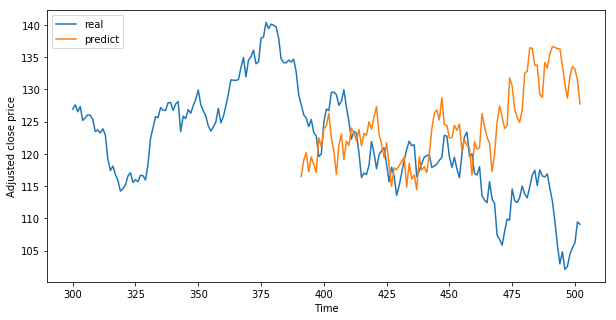

In [12]:
result = evaluate()
result = min_max_scaler.inverse_transform(result)[0]
real = rawdata["ma"].to_numpy()
real = min_max_scaler.inverse_transform(real.reshape(-1,1))[:,0]

fig = plt.figure(figsize=(10,5))
plt.plot(range(300,503-j),real[300:], label="real")
plt.plot(range(503-16*7,503),result, label="predict")
plt.xlabel("Time")
plt.ylabel("Adjusted close price")
plt.legend()
plt.show()
#fig.savefig("C:/Users/le/Desktop/TimeSeriesForecast-Transformer-main/TimeSeriesForecast-Transformer-main/result/%s-C2max3.png"%(3))

In [13]:
def MAE(y_pred, y_true):
    return np.mean(np.abs(y_true - y_pred))

def MSE(y_pred, y_true):
    return np.mean((y_true - y_pred) ** 2)

def RMSE(y_pred, y_true):
    return np.sqrt(MSE(y_pred, y_true))

def ACC(y_pred, y_true):
    return np.mean(1 - np.abs(y_true - y_pred) / y_true) * 100

In [14]:
print(MSE(result, real[-16*7:]))
print(RMSE(result, real[-16*7:]))
print(MAE(result, real[-16*7:]))
print(ACC(result, real[-16*7:]))

157.80544424642974
12.562063693773796
9.36501877826365
91.70640896793174


In [15]:
print(torch.__version__) 

1.12.0


In [16]:
torch.tensor(data_train[-219:]).reshape(1,-1,1).size()

torch.Size([1, 219, 1])

#        self.linear0 = nn.Sequential(Conv1D(100, 10, activation='relu', input_shape=(503 - iw - 2*ow, 1)),
                                    Conv1D(100, 10, activation='relu'),
                                    MaxPooling1D(3),
                                    Conv1D(160, 10, activation='relu'),
                                    Conv1D(160, 10, activation='relu'),
                                    GlobalAveragePooling1D(),
                                    Dropout(0.5),
                                    Dense(num_classes, activation='softmax')
                                    )

## 